In [61]:
import pandas as pd
import numpy as np
import tensorflow as tf
# tf.compat.v1.disable_v2_behavior()
from src.common.utils import get_root_directory
import matplotlib.pyplot as plt
from src.preprocessing.data_loader import DataLoader as dl
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import mlflow
import mlflow.keras
# import keras
# import timeshap

In [131]:
np.random.seed(42)
tf.random.set_seed(42)
lags = 30
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

ERROR! Session/line number was not unique in database. History logging moved to new session 576


In [132]:
root_dir = get_root_directory()
DL = dl(root_dir)
DL.load_data()
DL.merge_selected_data(selected_data=['BTC','sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt',
       'D_VADER_AvgScr_In', 'D_VADER_Sent_AvgIn', 'D_VADER_AvgScr_Ex',
       'D_VADER_Sent_AvgEx', 'D_FINBERT_AvgScr_In', 'D_FINBERT_Sent_AvgIn',
       'D_FINBERT_AvgScr_Ex', 'D_FINBERT_Sent_AvgEx', 'D_CRYPTOBERT_AvgScr_In',
       'D_CRYPTOBERT_Sent_AvgIn', 'D_CRYPTOBERT_AvgScr_Ex',
       'D_CRYPTOBERT_Sent_AvgEx'],
      dt

In [133]:
features = ['ETH_D_AvgPrc','D_VADER_AvgScr_In']
DL.select_features(features=features)
DL.set_time_range(start_date=start_date, end_date=end_date)

In [134]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer, Reshape, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanSquaredError

In [135]:
model=Sequential()
model.add(InputLayer((lags,len(features))))
# model.add(Bidirectional(LSTM(64, return_sequences=True)))
# model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(64, recurrent_dropout=0.2, return_sequences=False)))
# model.add(Bidirectional(LSTM(50, return_sequences=False)))
# model.add(Dense(8, "relu"))
model.add(Dense(n_periods))
model.summary()
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=100, verbose=0)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_13 (Bidirectional)     │ (None, 30, 128)             │          34,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_14 (Bidirectional)     │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,023 (523.53 KB)

 Trainable params: 134,023 (523.53 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
split = "val"
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_size=split_size, split_type="train_val")
y_train, x_train = DL.generate_X_y_tensors(train, data_split="train", lags=lags)
y_val, x_val = DL.generate_X_y_tensors(val, data_split=split, lags=lags)

In [137]:
model_history = model.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=500, batch_size=64, callbacks=[early_stop])

Epoch 1/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - loss: 0.1381 - root_mean_squared_error: 0.3684 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0595
Epoch 2/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0218 - root_mean_squared_error: 0.1471 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0415
Epoch 3/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0119 - root_mean_squared_error: 0.1089 - val_loss: 6.3324e-04 - val_root_mean_squared_error: 0.0252
Epoch 4/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0089 - root_mean_squared_error: 0.0942 - val_loss: 7.6728e-04 - val_root_mean_squared_error: 0.0277
Epoch 5/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0069 - root_mean_squared_error: 0.0828 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0327
Epoch 6/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0063 - root_mean_squared_error: 0.0793 - val_loss: 9.6335e-04 - val_root_mean_squared_error: 0.0310
Epoch 7/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 

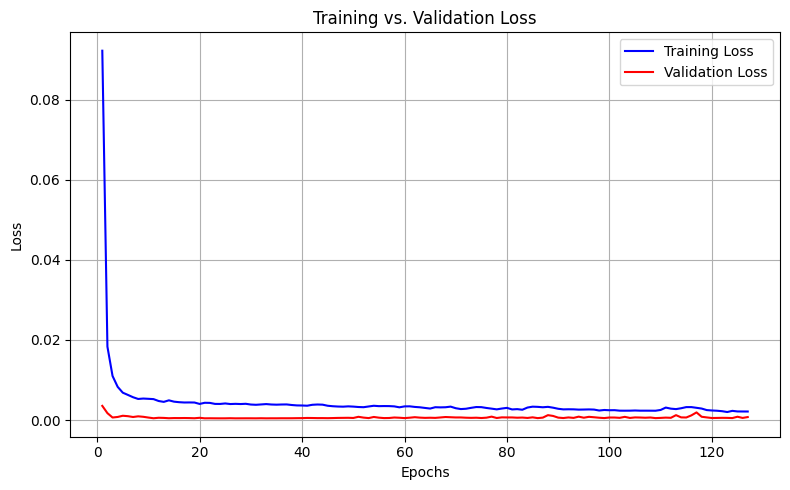

In [138]:
train_loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [139]:
import shap
explainer = shap.GradientExplainer(model, x_val)
shap_values = explainer.shap_values(x_val)

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_50
Received: inputs=['Tensor(shape=(103, 30, 2))']
  warnings.warn(msg)
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_50
Received: inputs=['Tensor(shape=(50, 30, 2))']
  warnings.warn(msg)


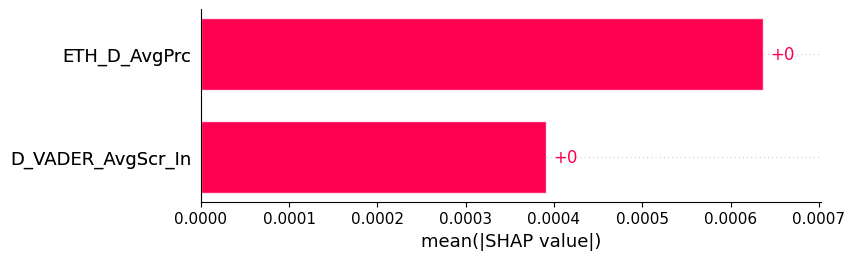

In [140]:
target_class = 0
shap_vals_all_classes = shap_values.mean(axis=-1)
shap_vals_reshaped = shap_vals_all_classes.reshape(-1, shap_values.shape[2])  
x_val_reshaped = x_val.reshape(-1, x_val.shape[2]) 
feature_names = [str(i) for i in range(x_val.shape[2])]
explanation = shap.Explanation(
    values=shap_vals_reshaped,    
    data=x_val_reshaped,
    feature_names=features
)
shap.plots.bar(explanation)

In [25]:
global_mean_per_timestep = shap_values_mean.mean(axis=0)
import matplotlib.pyplot as plt

plt.plot(global_mean_per_timestep)
plt.xlabel("Time Step")
plt.ylabel("Average SHAP Value")
plt.title("Mean SHAP Value per Time Step (Averaged Across Outputs)")
plt.grid()
plt.show()

NameError: name 'shap_values_mean' is not defined

In [26]:
avg_explanation = shap.Explanation(
    values=shap_values.values.mean(axis=2) ,
    base_values=np.mean(shap_values.base_values, axis=1),  # shape: (931,)
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [40]:
mean_shap.shape

(123, 10, 1)

In [27]:
global_importance = np.mean(np.abs(shap_values), axis=0)

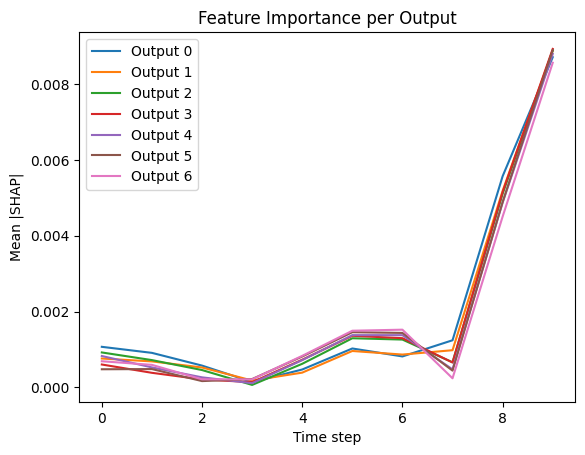

In [28]:
import matplotlib.pyplot as plt

for k in range(shap_values.shape[-1]):
    plt.plot(global_importance[:, 0, k], label=f'Output {k}')
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Mean |SHAP|")
plt.title("Feature Importance per Output")
plt.show()

### Walk-forward sliding window

In [38]:
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_size=split_size, split_type="train_val")

In [39]:
train_append = pd.concat([train, val[0:1]], ignore_index=False)
train_append

,ETH_D_AvgPrc
Date,
2021-01-01,734.267502
2021-01-02,752.461395
2021-01-03,882.036545
2021-01-04,1020.696609
2021-01-05,1064.421906
...,...
2023-02-28,1621.815369
2023-03-01,1633.614105
2023-03-02,1651.379883


In [41]:
y_train, x_train = DL.generate_X_y_tensors(train, data_split="train")
y_val, x_val = DL.generate_X_y_tensors(val, data_split=split)

In [44]:
x_val[1]

<xarray.DataArray 'X' (Lag: 5, Feature: 1)> Size: 40B
array([[0.20655799],
       [0.20611197],
       [0.20506307],
       [0.20176445],
       [0.18578641]])
Coordinates:
    Date     datetime64[ns] 8B 2023-03-10
  * Lag      (Lag) int32 20B 5 4 3 2 1
  * Feature  (Feature) <U12 48B 'ETH_D_AvgPrc'

In [7]:
predictions = []
split = "validation"
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_size=split_size, split_type="train_val", overlap=True, overlap_size=5)
train_iter = train
if split.lower() == "validation":
    iterations = len(val) - n_periods - lags +1
    iter_array = val
elif split.lower() == "test":
    iterations = len(test) - n_periods - lags +1
    iter_array = test
for t in range(iterations):
    y_train, x_train = DL.generate_X_y_tensors(train_iter, data_split="train")
    y_val, x_val = DL.generate_X_y_tensors(iter_array, data_split=split)
    predictions.append([0,1,2,4,5,6])
    train_iter = pd.concat([train_iter, iter_array[0:1]], ignore_index=False)
    iter_array = iter_array[1:]

Shape of full_x train: (781, 5, 1)
Shape of full_x val: (133, 5, 1)
Shape of full_x train: (782, 5, 1)
Shape of full_x val: (132, 5, 1)
Shape of full_x train: (783, 5, 1)
Shape of full_x val: (131, 5, 1)
Shape of full_x train: (784, 5, 1)
Shape of full_x val: (130, 5, 1)
Shape of full_x train: (785, 5, 1)
Shape of full_x val: (129, 5, 1)
Shape of full_x train: (786, 5, 1)
Shape of full_x val: (128, 5, 1)
Shape of full_x train: (787, 5, 1)
Shape of full_x val: (127, 5, 1)
Shape of full_x train: (788, 5, 1)
Shape of full_x val: (126, 5, 1)
Shape of full_x train: (789, 5, 1)
Shape of full_x val: (125, 5, 1)
Shape of full_x train: (790, 5, 1)
Shape of full_x val: (124, 5, 1)
Shape of full_x train: (791, 5, 1)
Shape of full_x val: (123, 5, 1)
Shape of full_x train: (792, 5, 1)
Shape of full_x val: (122, 5, 1)
Shape of full_x train: (793, 5, 1)
Shape of full_x val: (121, 5, 1)
Shape of full_x train: (794, 5, 1)
Shape of full_x val: (120, 5, 1)
Shape of full_x train: (795, 5, 1)
Shape of full

In [12]:
preds = np.array(predictions)

In [15]:
y_val, x_val = DL.generate_X_y_tensors(val, data_split=split)

Shape of full_x val: (133, 5, 1)


In [16]:
y_val.shape

(133, 7)

In [6]:
iter_array

,ETH_D_AvgPrc
Date,
2023-07-13,1938.733276
2023-07-14,1968.149841
2023-07-15,1936.200684
2023-07-16,1928.662964
2023-07-17,1911.659607
2023-07-18,1901.120789
2023-07-19,1897.284180
2023-07-20,1894.760406


In [ ]:
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_size=split_size, split_type="train_val", overlap=True, overlap_size=5)
predictions = []
purpose = "train"
split = "validation"
experiment_name = f"BiLSTM_{purpose}_{split}"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name=f"ETH_lag"):
    mlflow.keras.autolog()
    train_iter = train
    if split.lower() == "validation":
        iteriterations = len(test) - n_periods + 1
        iter_array = testations = len(val) - n_periods + 1
        iter_array = val
    elif split.lower() == "test":
        
    for t in range(len(iterations)):
        y_train, x_train = DL.generate_X_y_tensors(train_iter, data_split="train")
        y_val, x_val = DL.generate_X_y_tensors(iter_array, data_split=split)
        model.fit(x_train, y_train, epochs=500, batch_size=64)
        forecast = model.predict(x_val[t])
        predictions.append(forecast.flatten().tolist())
        train_iter = pd.concat([train_iter, val[t:t+1]], ignore_index=False)
        iter_array = iter_array[t+1:]
    mse_list = []
    rmse_list = []
    mae_list = []
    mape_list = []
    transposed = collate_array_elements(predictions)
    for i in range(len(transposed)):
        mse = mean_squared_error(target_array[i:-n_periods+i,i], transposed[i])
        rmse = root_mean_squared_error(target_array[i:-n_periods+i,i], transposed[i])
        mae = mean_absolute_error(target_array[i:-n_periods+i,i], transposed[i])
        mape = mean_absolute_percentage_error(target_array[i:-n_periods+i,i], transposed[i])
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        mlflow.log_metrics({"mse_daily":mse_list[i], "rmse_daily":rmse_list[i], "mae_daily":mae_list[i], "mape_daily":mape_list[i]}, step=(i+1))
    avg_mse = sum(mse_list)/len(mse_list)
    avg_rmse = sum(rmse_list)/len(rmse_list)
    avg_mae = sum(mae_list)/len(mae_list)
    avg_mape = sum(mape_list)/len(mape_list)
    mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse, "avg_mae": avg_mae, "avg_mape": avg_mape})
mlflow.end_run()

In [141]:
result = model.predict(x_val)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step


In [142]:
_,y_scaler = DL.get_scalers()

In [143]:
result_rev = y_scaler.inverse_transform(result)

In [144]:
rmse_daily = []
y_true = y_scaler.inverse_transform(y_val)
for i in range(result_rev.shape[1]):
    rmse = root_mean_squared_error(y_true[:,i], result_rev[:,i])
    rmse_daily.append(rmse)

In [145]:
rmse_daily

[41.00051804202674,
 55.24437763553356,
 68.18001400033661,
 78.55955935094684,
 87.2775809488141,
 95.91533160658443,
 97.83829463594716]

In [78]:
rmse_daily

[29.3987405616717,
 53.966050641414704,
 70.47175660099639,
 82.26009085056143,
 88.9829705170639,
 98.38767386012343,
 103.97364358866122]

In [158]:
result = model.predict(x_test)
result_rev = y_scaler.inverse_transform(result)
rmse_daily = []
y_true = y_scaler.inverse_transform(y_test)
for i in range(result_rev.shape[1]):
    rmse = root_mean_squared_error(y_true[:,i], result_rev[:,i])
    rmse_daily.append(rmse)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [159]:
rmse_daily

[33.13259747498835,
 51.48555055082277,
 64.01929667002126,
 73.2159838856719,
 81.89189633572397,
 90.22517887497129,
 98.50544379610115]